In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import your actual data loader and constants
from cooltrack.data_loader import load_grid
from cooltrack.constants import INDEPENDENT_DIMS, SECONDS_PER_YR, R_J

# Setup Plotting
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

# =====================================================================
# 1. LOAD THE DATA & SPIN UP THE ENGINE
# =====================================================================
# (Make sure 'load_grid' is imported at the top of your notebook)
#GRID_PATH = "../../exoweave/outputs/master_grid_cloudless_cooltrack.h5" 
GRID_PATH = "../data/master_grid_cooltrack.h5" 

print("Loading grid...")
df = load_grid(GRID_PATH)

# Clean the grid as usual
if 'dsdt' not in df.columns and 'dsdt_J_K_kg_s' in df.columns:
    df['dsdt'] = df['dsdt_J_K_kg_s']
df = df[(df['T_int'] > 0) & (df['dsdt'] < 0)].copy()
df['ln_Tint'] = np.log(df['T_int'])
df['ln_tau'] = -np.log(np.abs(df['dsdt']))
#clean_cols = INDEPENDENT_DIMS + ['ln_Tint', 'S_physical', 'ln_tau']
#df = df.dropna(subset=clean_cols).reset_index(drop=True)
df['Radius_Rj'] = df['Req']/R_J


2026-05-28 15:33:33,294 - INFO - ⏳ Parquet cache not found or disabled. Running parallel HDF5 extraction...
2026-05-28 15:33:33,298 - INFO - Loading Exoweave HDF5 file: ../data/master_grid_cooltrack.h5...


Loading grid...


2026-05-28 15:33:34,334 - INFO - Spinning up 7 workers to read HDF5 across network...
Reading HDF5 Chunks: 100%|██████████| 29/29 [03:01<00:00,  6.28s/it]


Extracted 30981 models from Exoweave HDF5 file.


2026-05-28 15:36:45,395 - INFO - ✅ Exoweave Grid loaded and mapped successfully. Final shape: (30447, 301)
2026-05-28 15:36:45,566 - INFO - 💾 Saving extracted grid to cache: ../data/master_grid_cooltrack_cache.parquet


2026-05-28 15:44:59,323 - INFO - Loaded initial condition interpolators from 8 files.


Spinning up CoolTrack Engine...
Generating comparative tracks...


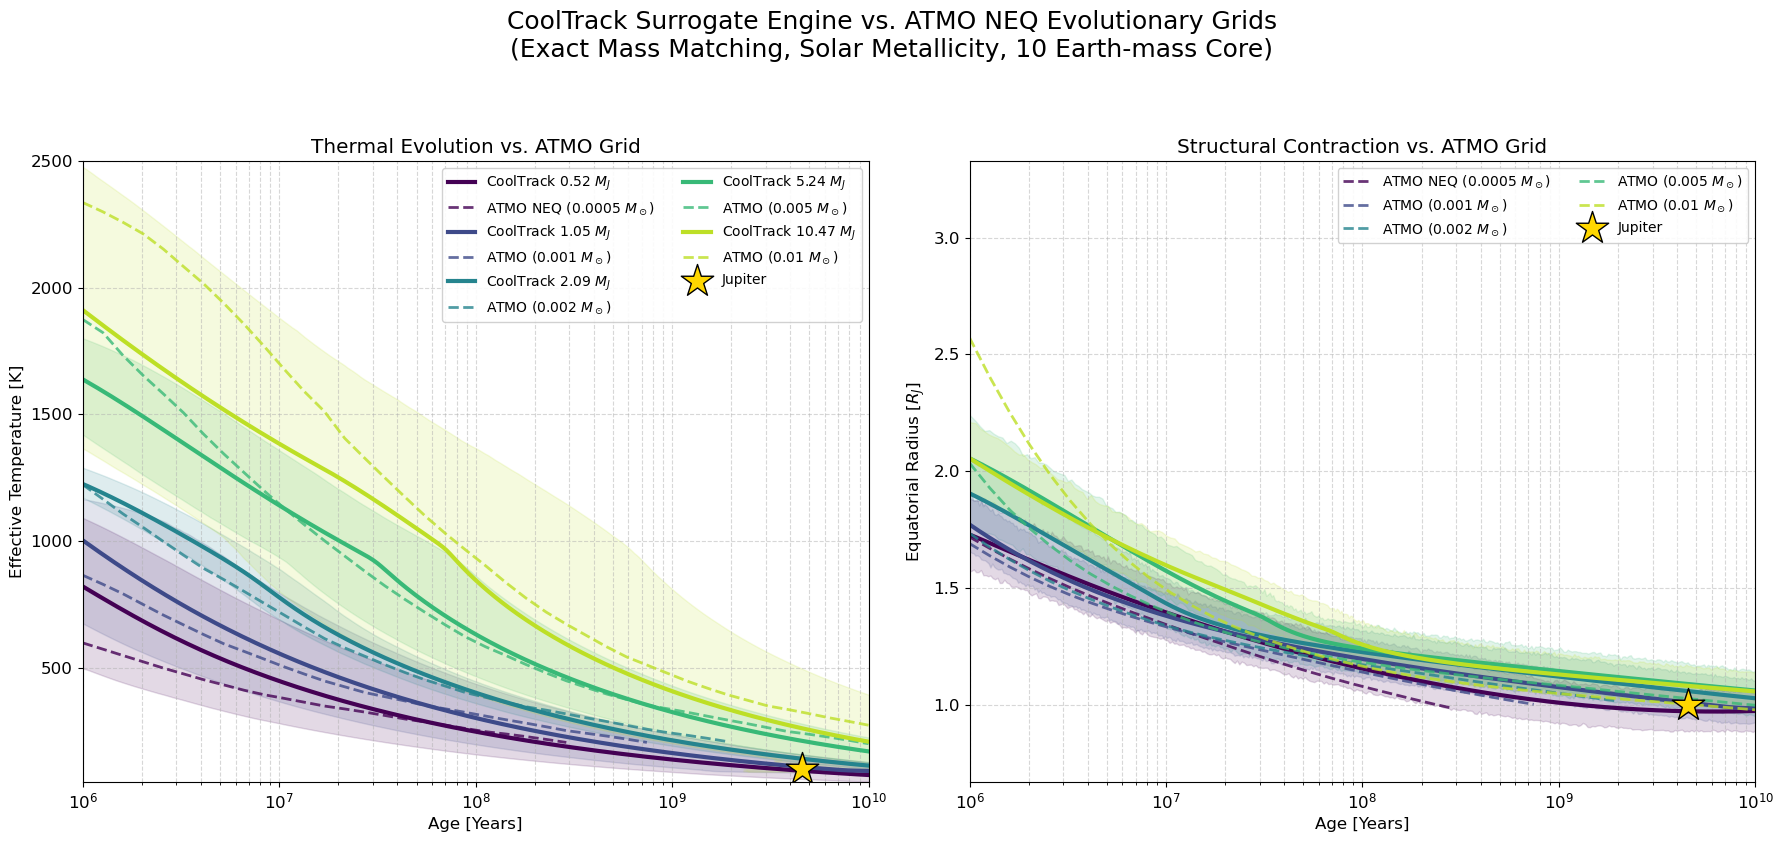

In [8]:
# Initialize the Engine!
from cooltrack.initial_conditions import InitialConditions
from cooltrack.cooltrack import SemiAnalyticalCoolTrack
import os
import numpy as np
import matplotlib.pyplot as plt

AGE_DATA_PATH = "../data/age_data" 
init_conds = InitialConditions(age_data_path=AGE_DATA_PATH)

print("Spinning up CoolTrack Engine...")
engine = SemiAnalyticalCoolTrack(df, init_conds, INDEPENDENT_DIMS, bandwidth=0.5)

# =====================================================================
# 2. SET UP THE ATMO LOADER
# =====================================================================
ATMO_DIR = "/Users/cwilkinson/Documents/Work/Observatoire de Paris/Research/Research/Codes/cooltrack/data/ATMO_2020_models/evolutionary_tracks/ATMO_NEQ_weak/JWST_photometry/JWST_phot_MIRI"
M_SUN_TO_MJUP = 1047.3486
R_SUN_TO_RJUP = 9.731

def load_atmo_track(target_mass_mjup, atmo_dir):
    """Finds the closest ATMO mass file and extracts Age, Teff, and Radius."""
    target_mass_msun = target_mass_mjup / M_SUN_TO_MJUP
    files = [f for f in os.listdir(atmo_dir) if f.endswith("_ATMO_NEQ_weak_vega_MIRI.txt")]
    
    file_masses = [float(f.split('_')[0]) for f in files]
    closest_idx = np.argmin(np.abs(np.array(file_masses) - target_mass_msun))
    closest_file = files[closest_idx]
    
    filepath = os.path.join(atmo_dir, closest_file)
    data = np.loadtxt(filepath, skiprows=2)
    
    age_yr = data[:, 1] * 1e9
    teff_k = data[:, 2]
    radius_rj = data[:, 4] * R_SUN_TO_RJUP
    
    return age_yr, teff_k, radius_rj, file_masses[closest_idx]

# =====================================================================
# 3. RUN THE COMPARISON LOOP & PLOT
# =====================================================================
print("Generating comparative tracks...")

# --- Define exact ATMO masses in M_sun and convert to M_jup ---
atmo_masses_msun = [0.0005, 0.001, 0.002, 0.005, 0.01]
masses_to_test = [m * M_SUN_TO_MJUP for m in atmo_masses_msun]

colors = plt.cm.viridis(np.linspace(0, 0.9, len(masses_to_test)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for idx, mass in enumerate(masses_to_test):
    # A. COOLTRACK SURROGATE
    target_planet = {
    'mass_Mj': mass, 
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 3.0,  # <-- Need both now!
    'f_sed_volatile': 3.0,    # <-- Need both now!
    'kzz': 8.0
}
    
    fits = engine.fit_surrogate(target_planet)
    track_df = engine.evolve(fits, start_type=19, n_points=500) 
    
    # Drop the t=0 singularity to prevent log-scale crashes
    plot_df = track_df[track_df['age_yr'] > 0].copy()
    
    label_mass = round(mass, 2)
    
    # ---------------------------------------------------------
    # Plot Thermal (CoolTrack) - ax1
    # ---------------------------------------------------------
    ax1.plot(plot_df['age_yr'], plot_df['T_int'], 
             color=colors[idx], linewidth=3, label=f'CoolTrack {label_mass} $M_J$')
             
    ax1.fill_betweenx(plot_df['T_int'], plot_df['age_yr_lower'], plot_df['age_yr_upper'], 
                      color=colors[idx], alpha=0.15)

    # ---------------------------------------------------------
    # Plot Structural (CoolTrack) - ax2
    # ---------------------------------------------------------
    ax2.plot(plot_df['age_yr'], plot_df['Req_Rj'], 
             color=colors[idx], linewidth=3)
             
    ax2.fill_between(plot_df['age_yr'], plot_df['Req_Rj_lower'], plot_df['Req_Rj_upper'], 
                     color=colors[idx], alpha=0.15)

    # ---------------------------------------------------------
    # B. ATMO LITERATURE
    # ---------------------------------------------------------
    atmo_age, atmo_teff, atmo_rad, atmo_msun = load_atmo_track(mass, ATMO_DIR)
    
    # To keep the legend clean, we'll only label the ATMO tracks once if you prefer, 
    # but here they are kept with unique labels per mass.
    atmo_label = f'ATMO NEQ ({atmo_msun} $M_\odot$)' if idx == 0 else f'ATMO ({atmo_msun} $M_\odot$)'
    
    # THE FIX: Swapped color='black' for color=colors[idx]
    ax1.plot(atmo_age, atmo_teff, color=colors[idx], linestyle='--', linewidth=2, alpha=0.8, label=atmo_label)
    ax2.plot(atmo_age, atmo_rad, color=colors[idx], linestyle='--', linewidth=2, alpha=0.8, label=atmo_label)

# Add Benchmarks
ax1.scatter(4.56e9, 99.0, color='gold', edgecolor='black', marker='*', s=600, zorder=10, label='Jupiter')
ax2.scatter(4.56e9, 1.0, color='gold', edgecolor='black', marker='*', s=600, zorder=10, label='Jupiter')

# Format Plots
ax1.set(xscale='log', xlim=(1e6, 1e10), ylim=(50, 2500), xlabel='Age [Years]', ylabel='Effective Temperature [K]', title='Thermal Evolution vs. ATMO Grid')
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(fontsize=10, loc='upper right', ncol=2, framealpha=0.9)

bottom, top = ax2.get_ylim()
ax2.set(xscale='log', xlim=(1e6, 1e10), ylim=(max(0.5, bottom - 0.1), top + 0.1), xlabel='Age [Years]', ylabel='Equatorial Radius [$R_J$]', title='Structural Contraction vs. ATMO Grid')
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend(fontsize=10, loc='upper right', ncol=2, framealpha=0.9)

fig.suptitle('CoolTrack Surrogate Engine vs. ATMO NEQ Evolutionary Grids\n(Exact Mass Matching, Solar Metallicity, 10 Earth-mass Core)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

<>:111: SyntaxWarning: invalid escape sequence '\o'
<>:111: SyntaxWarning: invalid escape sequence '\o'
<>:111: SyntaxWarning: invalid escape sequence '\o'
<>:111: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_96291/162843983.py:111: SyntaxWarning: invalid escape sequence '\o'
  atmo_label = f'ATMO NEQ ({atmo_msun:.3f} $M_\odot$)' if idx == 0 else f'ATMO ({atmo_msun:.3f} $M_\odot$)'
/tmp/ipykernel_96291/162843983.py:111: SyntaxWarning: invalid escape sequence '\o'
  atmo_label = f'ATMO NEQ ({atmo_msun:.3f} $M_\odot$)' if idx == 0 else f'ATMO ({atmo_msun:.3f} $M_\odot$)'


Generating comparative photometry tracks...
Radius fit successful with R²=0.970
Radius fit parameters: [11.21867531  0.54090413 -0.5         6.08479143  5.        ]


Radius fit successful with R²=0.978
Radius fit parameters: [11.30081027  0.71998534 -0.37682289  6.77575316  5.        ]
Radius fit successful with R²=0.976
Radius fit parameters: [11.44407874  1.19181374 -0.23107388  9.77072712  5.        ]
Radius fit successful with R²=0.966
Radius fit parameters: [11.41512716  0.94934467 -0.19689244  7.94117989  5.        ]


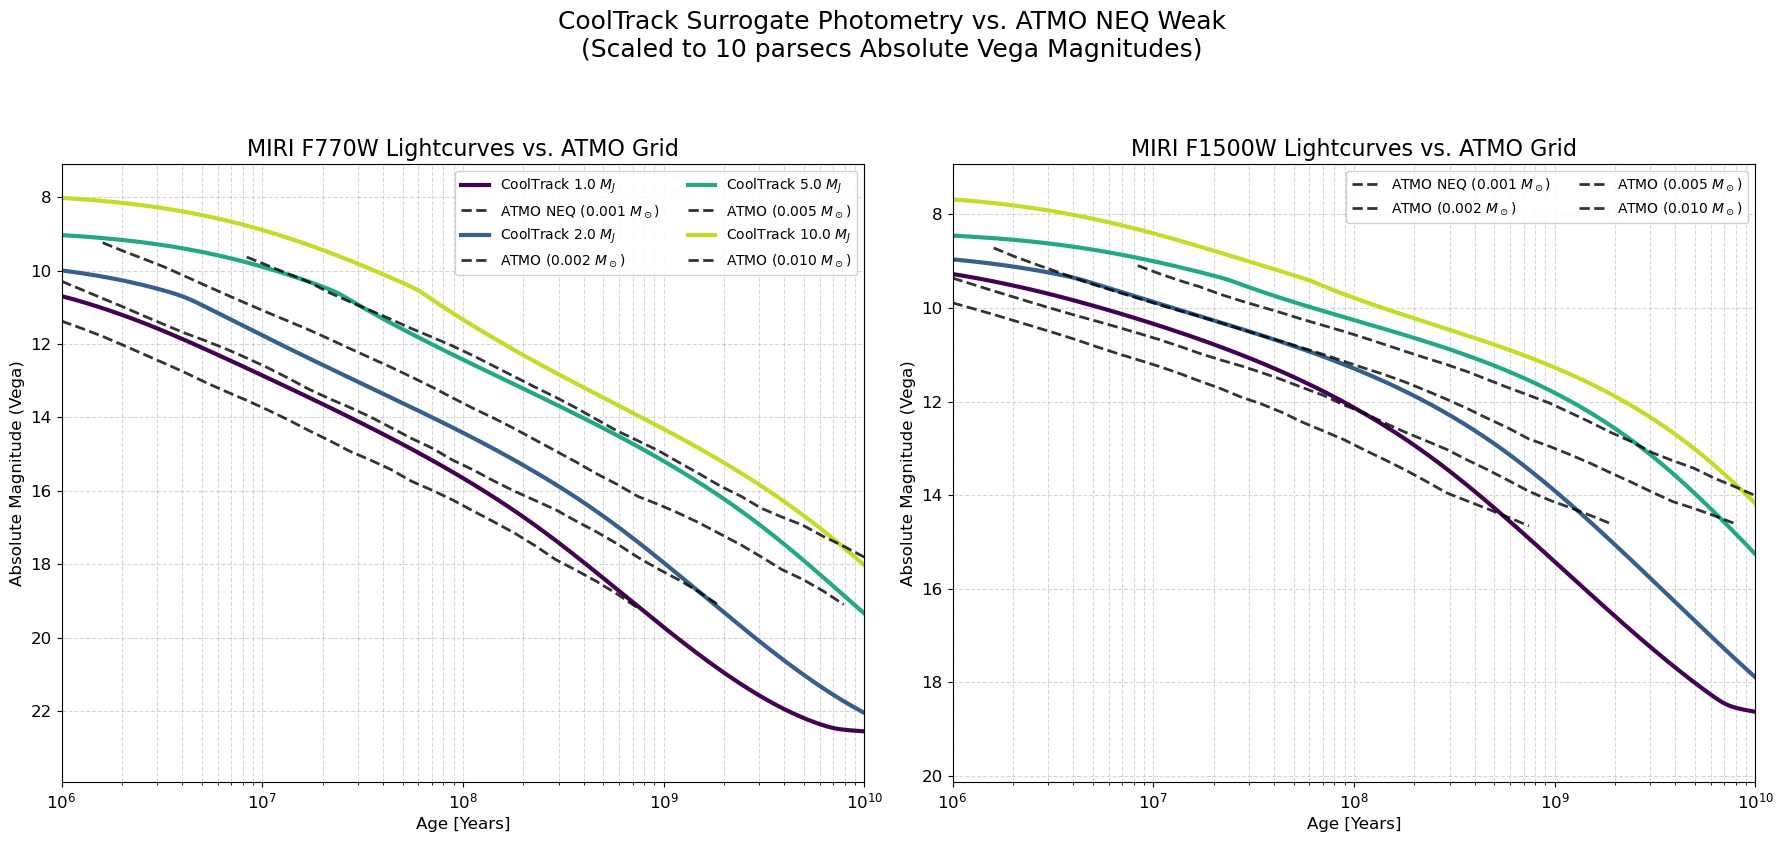

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. SET UP THE ATMO PHOTOMETRY LOADER
# =====================================================================
ATMO_DIR = "/travail/cwilkinson/cooltrack/data/ATMO_2020_models/evolutionary_tracks/ATMO_NEQ_weak/JWST_photometry/JWST_phot_MIRI"
M_SUN_TO_MJUP = 1047.3486

def load_atmo_photometry(target_mass_mjup, atmo_dir):
    """Finds the closest ATMO mass file and extracts Age, F770W, and F1500W Vega magnitudes."""
    target_mass_msun = target_mass_mjup / M_SUN_TO_MJUP
    files = [f for f in os.listdir(atmo_dir) if f.endswith("_ATMO_NEQ_weak_vega_MIRI.txt")]
    
    file_masses = [float(f.split('_')[0]) for f in files]
    closest_idx = np.argmin(np.abs(np.array(file_masses) - target_mass_msun))
    closest_file = files[closest_idx]
    
    filepath = os.path.join(atmo_dir, closest_file)
    data = np.loadtxt(filepath, skiprows=2)
    
    # ATMO Columns (0-indexed based on your file): 
    # 1: Age(Gyr), 7: MIRI-F770W, 11: MIRI-F1500W
    age_yr = data[:, 1] * 1e9
    mag_770 = data[:, 7]
    mag_1500 = data[:, 11]
    
    # Filter out the 0.0000 dummy values at very young ages in the ATMO file
    valid = mag_770 > 0.0
    
    return age_yr[valid], mag_770[valid], mag_1500[valid], file_masses[closest_idx]

# =====================================================================
# 2. COOLTRACK MAGNITUDE CONVERSION (10 PARSECS)
# =====================================================================
R_J_M = 7.1492e7
PC_10_M = 3.08567758e17
SCALE_FACTOR_LOG = 2 * np.log10(R_J_M / PC_10_M) # Approx -19.270

# Vega Zero-Point Fluxes [log10(W/m^2/um)]
# Updated to match the new filter string names from constants.py
VEGA_FLUX_LOG = {
    'log_JWST/MIRI.F770W': -11.817, 
    'log_JWST/MIRI.F1500W': -12.974
}

def surface_flux_to_abs_mag(log_flux_surf, radius_rj, band):
    """Converts log10 surface flux to Absolute Vega Magnitude at 10 pc."""
    log_flux_10pc = log_flux_surf + 2 * np.log10(radius_rj) + SCALE_FACTOR_LOG
    return -2.5 * (log_flux_10pc - VEGA_FLUX_LOG[band])

# =====================================================================
# 3. RUN THE COMPARISON LOOP
# =====================================================================
print("Generating comparative photometry tracks...")
masses_to_test = [1.0, 2.0, 5.0, 10.0] 
colors = plt.cm.viridis(np.linspace(0, 0.9, len(masses_to_test)))

# Create Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Define the exact target bands we are comparing against ATMO
bands_to_track = [
    'log_JWST/MIRI.F770W', 
    'log_JWST/MIRI.F1500W'
]

for idx, mass in enumerate(masses_to_test):
    # --- A. COOLTRACK SURROGATE ---
    target_planet = {'mass_Mj': mass, 'T_irr': 100.0, 'Met': 0.0, 'core': 10.0, 
    'f_sed_refractory': 3.0, 
    'f_sed_volatile': 3.0, 
    'kzz': 8.0}
    
    # Fit engine and evolve
    fits = engine.fit_surrogate(target_planet, photometry_bands=bands_to_track)
    
    # We pass start_type=10 assuming this is a valid bin index in your init_conds
    track_df = engine.evolve(fits, start_type=10, n_points=500) 
    
    # Convert CoolTrack fluxes to Absolute Magnitudes 
    # (Notice Req_Rj replaces Radius_Rj here)
    mag_770_cool = surface_flux_to_abs_mag(track_df[bands_to_track[0]], track_df['Req_Rj'], bands_to_track[0])
    mag_1500_cool = surface_flux_to_abs_mag(track_df[bands_to_track[1]], track_df['Req_Rj'], bands_to_track[1])
    
    # Do the same for the 1-sigma bounds (Cross-matching flux variance with radius variance)
    mag_770_lower_bound = surface_flux_to_abs_mag(track_df[f"{bands_to_track[0]}_upper"], track_df['Req_Rj_upper'], bands_to_track[0])
    mag_770_upper_bound = surface_flux_to_abs_mag(track_df[f"{bands_to_track[0]}_lower"], track_df['Req_Rj_lower'], bands_to_track[0])
    
    mag_1500_lower_bound = surface_flux_to_abs_mag(track_df[f"{bands_to_track[1]}_upper"], track_df['Req_Rj_upper'], bands_to_track[1])
    mag_1500_upper_bound = surface_flux_to_abs_mag(track_df[f"{bands_to_track[1]}_lower"], track_df['Req_Rj_lower'], bands_to_track[1])
    
    # Plot CoolTrack F770W
    ax1.plot(track_df['age_yr'], mag_770_cool, color=colors[idx], linewidth=3, label=f'CoolTrack {mass} $M_J$')
    # ax1.fill_between(track_df['age_yr'], 
    #                  np.minimum(mag_770_lower_bound, mag_770_upper_bound), 
    #                  np.maximum(mag_770_lower_bound, mag_770_upper_bound), 
    #                  color=colors[idx], alpha=0.15)

    # Plot CoolTrack F1500W
    ax2.plot(track_df['age_yr'], mag_1500_cool, color=colors[idx], linewidth=3)
    # ax2.fill_between(track_df['age_yr'], 
    #                  np.minimum(mag_1500_lower_bound, mag_1500_upper_bound), 
    #                  np.maximum(mag_1500_lower_bound, mag_1500_upper_bound), 
    #                  color=colors[idx], alpha=0.15)

    # --- B. ATMO LITERATURE ---
    atmo_age, atmo_770, atmo_1500, atmo_msun = load_atmo_photometry(mass, ATMO_DIR)
    atmo_label = f'ATMO NEQ ({atmo_msun:.3f} $M_\odot$)' if idx == 0 else f'ATMO ({atmo_msun:.3f} $M_\odot$)'
    
    # Plot ATMO Magnitudes (Dashed Black Lines)
    ax1.plot(atmo_age, atmo_770, color='black', linestyle='--', linewidth=2, alpha=0.8, label=atmo_label)
    ax2.plot(atmo_age, atmo_1500, color='black', linestyle='--', linewidth=2, alpha=0.8, label=atmo_label)

# =====================================================================
# 4. FORMAT PLOTS 
# =====================================================================

# --- Format Panel 1: F770W ---
ax1.set(xscale='log', xlim=(1e6, 1e10), xlabel='Age [Years]', ylabel='Absolute Magnitude (Vega)')
ax1.set_title('MIRI F770W Lightcurves vs. ATMO Grid', fontsize=16)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.invert_yaxis() # CRITICAL: Invert so brighter (lower mag) goes UP
ax1.legend(loc='upper right', fontsize=10, ncol=2, framealpha=0.9)

# --- Format Panel 2: F1500W ---
ax2.set(xscale='log', xlim=(1e6, 1e10), xlabel='Age [Years]', ylabel='Absolute Magnitude (Vega)')
ax2.set_title('MIRI F1500W Lightcurves vs. ATMO Grid', fontsize=16)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.invert_yaxis() # CRITICAL: Invert so brighter (lower mag) goes UP
ax2.legend(loc='upper right', fontsize=10, ncol=2, framealpha=0.9)

fig.suptitle('CoolTrack Surrogate Photometry vs. ATMO NEQ Weak\n(Scaled to 10 parsecs Absolute Vega Magnitudes)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [5]:
track_df

,T_int,S_physical,tau,age_yr,Req_Rj,log_JWST/MIRI.F770W,log_JWST/MIRI.F1500W,age_yr_lower,age_yr_upper,S_physical_lower,S_physical_upper,Req_Rj_lower,Req_Rj_upper,log_JWST/MIRI.F770W_lower,log_JWST/MIRI.F770W_upper,log_JWST/MIRI.F1500W_lower,log_JWST/MIRI.F1500W_upper
0,1612.444206,81452.781404,3.486308e+10,0.000000e+00,1.806875,3.792964,2.772893,0.000000e+00,0.000000e+00,38783.884295,167083.160066,0.225323,13.562978,3.689298,3.900657,2.729175,2.822298
1,1603.090484,81321.300728,3.586627e+10,1.473424e+05,1.798726,3.787301,2.767011,7.259854e+04,3.170665e+05,38722.414980,166805.922979,0.226885,13.352631,3.689310,3.889962,2.720627,2.815418
2,1593.791021,81190.032288,3.689829e+10,2.986798e+05,1.790658,3.781558,2.761152,1.473394e+05,6.425931e+05,38661.043093,166529.145992,0.228457,13.146199,3.675132,3.885372,2.717340,2.804915
3,1584.545505,81058.975740,3.795999e+10,4.541204e+05,1.782670,3.775736,2.755314,2.242853e+05,9.767575e+05,38599.768478,166252.828341,0.230040,12.943603,3.675722,3.881271,2.709025,2.800049
4,1575.353622,80928.130744,3.905219e+10,6.137754e+05,1.774762,3.769834,2.749499,3.035009e+05,1.318686e+06,38538.590982,165976.969264,0.231633,12.744767,3.660990,3.877704,2.705084,2.795337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,90.529044,44432.297382,1.893624e+15,3.307914e+11,1.006983,-1.782242,-1.415228,6.834648e+10,1.028777e+12,23130.877774,77571.878563,0.989640,1.022027,-1.881817,-1.676348,-1.460196,-1.368481
496,90.003889,44142.613060,1.932201e+15,3.483511e+11,1.006831,-1.791281,-1.426903,6.975498e+10,1.053520e+12,23108.731939,77161.217486,0.994131,1.017919,-1.893617,-1.687124,-1.475969,-1.383173
497,89.481780,43853.331239,1.971565e+15,3.662436e+11,1.006724,-1.800179,-1.438484,7.122068e+10,1.078990e+12,23086.410699,76752.730374,0.998496,1.013957,-1.908889,-1.696726,-1.486759,-1.392067
498,88.962700,43564.776686,2.011730e+15,3.844547e+11,1.006661,-1.808934,-1.449968,7.268708e+10,1.104880e+12,23063.861153,76346.405736,1.002730,1.010142,-1.916823,-1.700440,-1.498679,-1.406609


Compiling ATMO literature grid...


Loaded 3001 ATMO states.
Loaded 13819 ExoWeave states.


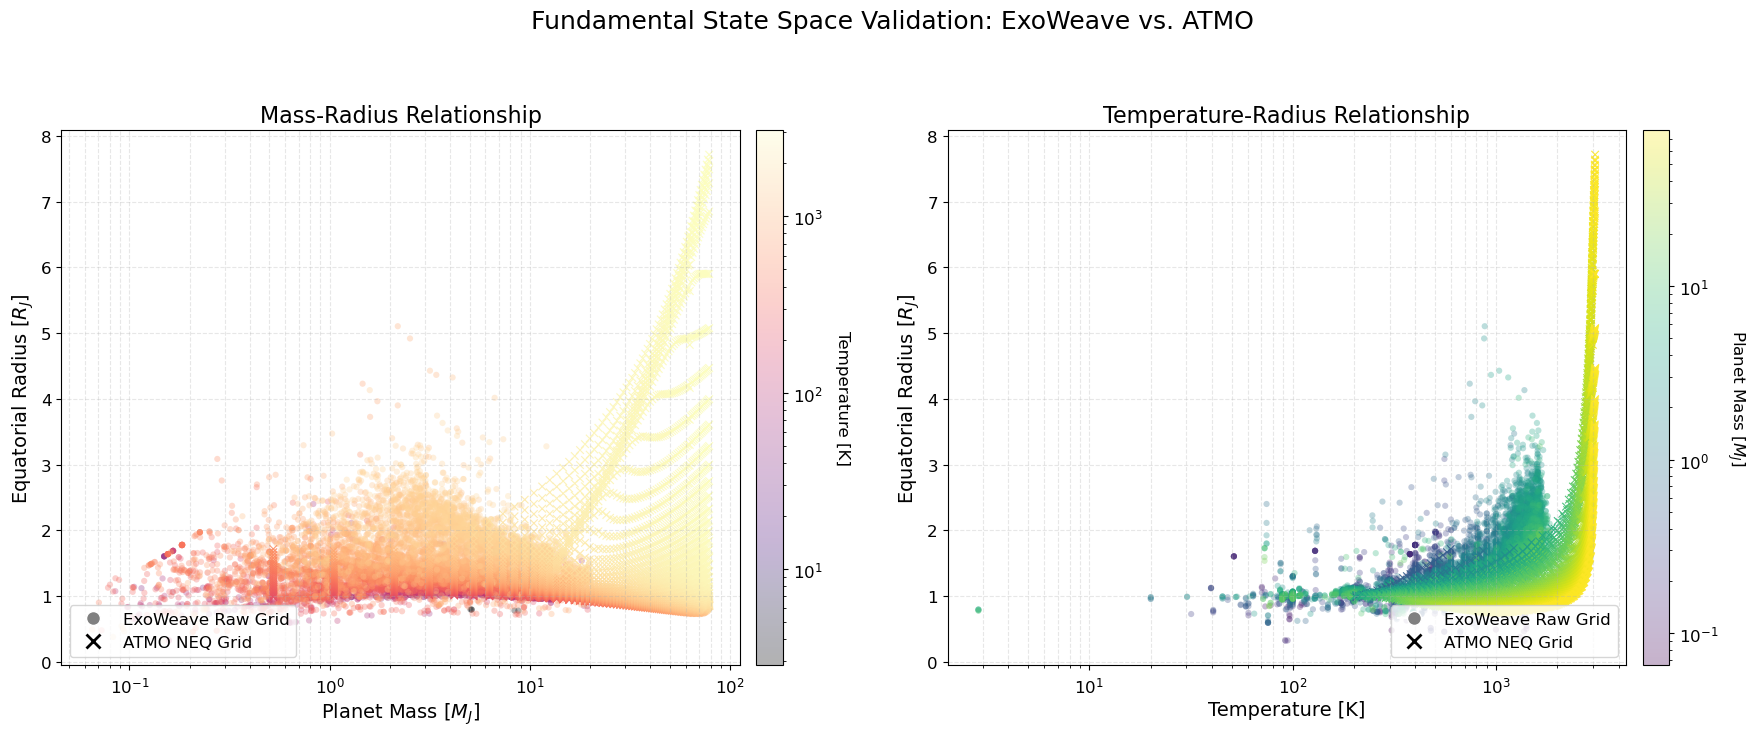

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

# =====================================================================
# 1. COMPILE THE FULL ATMO GRID
# =====================================================================
ATMO_DIR = "/travail/cwilkinson/cooltrack/data/ATMO_2020_models/evolutionary_tracks/ATMO_NEQ_weak/JWST_photometry/JWST_phot_MIRI"
M_SUN_TO_MJUP = 1047.3486
R_SUN_TO_RJUP = 9.731

print("Compiling ATMO literature grid...")
atmo_records = []

for f in os.listdir(ATMO_DIR):
    if f.endswith("_ATMO_NEQ_weak_vega_MIRI.txt"):
        # Extract mass from filename
        mass_msun = float(f.split('_')[0])
        mass_mjup = mass_msun * M_SUN_TO_MJUP
        
        filepath = os.path.join(ATMO_DIR, f)
        data = np.loadtxt(filepath, skiprows=2)
        
        # ATMO Columns: 2=Teff(K), 4=Radius(Rsun)
        teff_k = data[:, 2]
        radius_rj = data[:, 4] * R_SUN_TO_RJUP
        
        for t, r in zip(teff_k, radius_rj):
            atmo_records.append({
                'mass_Mj': mass_mjup,
                'T_int': t,  # ATMO Teff is functionally equivalent to Tint for older/isolated BDs
                'Req_Rj': r
            })

atmo_df = pd.DataFrame(atmo_records)
print(f"Loaded {len(atmo_df)} ATMO states.")
print(f"Loaded {len(df)} ExoWeave states.") # Assuming 'df' is already in memory

# =====================================================================
# 2. SETUP UNIFIED COLOR NORMS
# =====================================================================
# We need both datasets to use the exact same color scale to prove they match!
min_T = min(df['T_int'].min(), atmo_df['T_int'].min())
max_T = max(df['T_int'].max(), atmo_df['T_int'].max())

min_M = min(df['mass_Mj'].min(), atmo_df['mass_Mj'].min())
max_M = max(df['mass_Mj'].max(), atmo_df['mass_Mj'].max())

norm_T = LogNorm(vmin=min_T, vmax=max_T)
norm_M = LogNorm(vmin=min_M, vmax=max_M)

# =====================================================================
# 3. GENERATE THE SCATTER PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Sort to plot brightest/hottest points on top
df = df.sort_values('T_int')
atmo_df = atmo_df.sort_values('T_int')

# --- PANEL 1: Mass vs. Radius (Colored by T_int) ---
# 1. Plot ExoWeave (Circles, slightly transparent)
sc1 = ax1.scatter(df['mass_Mj'], df['Req_Rj'], c=df['T_int'], 
                  cmap='magma', norm=norm_T, s=20, alpha=0.3, edgecolors='none')

# 2. Plot ATMO (Crosses, crisp and opaque)
ax1.scatter(atmo_df['mass_Mj'], atmo_df['Req_Rj'], c=atmo_df['T_int'], 
            cmap='magma', norm=norm_T, s=30, alpha=0.9, marker='x', linewidths=0.8)

ax1.set_xscale('log')
ax1.set_xlabel('Planet Mass [$M_J$]', fontsize=14)
ax1.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax1.set_title('Mass-Radius Relationship', fontsize=16)
ax1.grid(True, which="both", ls="--", alpha=0.3)

cbar1 = plt.colorbar(sc1, ax=ax1, pad=0.02)
cbar1.set_label('Temperature [K]', rotation=270, labelpad=20)


# --- PANEL 2: Temperature vs. Radius (Colored by Mass) ---
df = df.sort_values('mass_Mj')
atmo_df = atmo_df.sort_values('mass_Mj')

# 1. Plot ExoWeave (Circles)
sc2 = ax2.scatter(df['T_int'], df['Req_Rj'], c=df['mass_Mj'], 
                  cmap='viridis', norm=norm_M, s=20, alpha=0.3, edgecolors='none')

# 2. Plot ATMO (Crosses)
ax2.scatter(atmo_df['T_int'], atmo_df['Req_Rj'], c=atmo_df['mass_Mj'], 
            cmap='viridis', norm=norm_M, s=30, alpha=0.9, marker='x', linewidths=0.8)

ax2.set_xscale('log')
ax2.set_xlabel('Temperature [K]', fontsize=14)
ax2.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax2.set_title('Temperature-Radius Relationship', fontsize=16)
ax2.grid(True, which="both", ls="--", alpha=0.3)

cbar2 = plt.colorbar(sc2, ax=ax2, pad=0.02)
cbar2.set_label('Planet Mass [$M_J$]', rotation=270, labelpad=20)


# =====================================================================
# 4. CUSTOM LEGENDS & TITLES
# =====================================================================
# Create custom legend handles to explain the markers
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='ExoWeave Raw Grid'),
    Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, markeredgewidth=2, label='ATMO NEQ Grid')
]

ax1.legend(handles=legend_elements, loc='lower left', fontsize=12)
ax2.legend(handles=legend_elements, loc='lower right', fontsize=12)

fig.suptitle('Fundamental State Space Validation: ExoWeave vs. ATMO', fontsize=18, y=1.05)

plt.tight_layout()
plt.show()

<>:97: SyntaxWarning: invalid escape sequence '\g'
<>:97: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_96291/3681370519.py:97: SyntaxWarning: invalid escape sequence '\g'
  fig.suptitle('Zoomed Fundamental State Space Validation ($\geq 1 M_J$, Solar Metallicity)', fontsize=18, y=1.05)


Filtered ExoWeave: 9672 points (Solar Met, M >= 1 Mjup)
Filtered ATMO: 2976 points (M >= 1 Mjup)


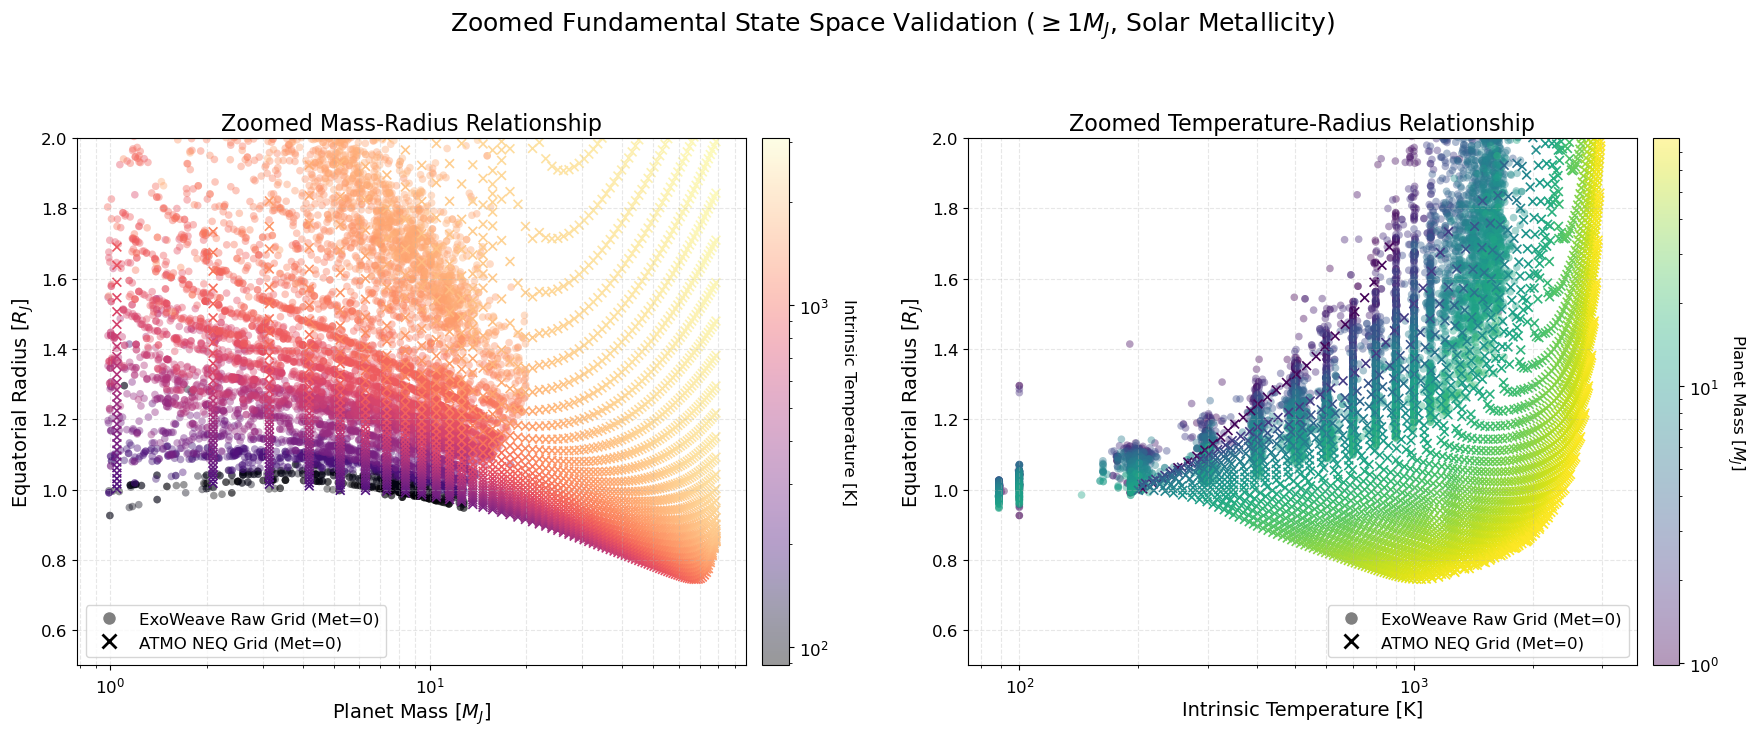

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

# =====================================================================
# 1. FILTER THE GRIDS (Zoom & Metallicity Control)
# =====================================================================
# We filter ExoWeave for Solar Metallicity (Met ~ 0) and Mass >= 1.0 Mjup
# We use np.isclose just in case of floating-point inaccuracies in the HDF5
df_sub = df[(np.isclose(df['Met'], 0.0, atol=0.01)) & (df['mass_Mj'] >= 0.98)].copy()

# The ATMO NEQ Weak grid is already Solar Metallicity, so we just filter by Mass
atmo_sub = atmo_df[atmo_df['mass_Mj'] >= 1.0].copy()

print(f"Filtered ExoWeave: {len(df_sub)} points (Solar Met, M >= 1 Mjup)")
print(f"Filtered ATMO: {len(atmo_sub)} points (M >= 1 Mjup)")

# =====================================================================
# 2. SETUP ZOOMED COLOR NORMS
# =====================================================================
# Recalculate color bounds based ONLY on the zoomed-in subset
min_T = min(df_sub['T_int'].min(), atmo_sub['T_int'].min())
max_T = max(df_sub['T_int'].max(), atmo_sub['T_int'].max())

min_M = min(df_sub['mass_Mj'].min(), atmo_sub['mass_Mj'].min())
max_M = max(df_sub['mass_Mj'].max(), atmo_sub['mass_Mj'].max())

norm_T = LogNorm(vmin=min_T, vmax=max_T)
norm_M = LogNorm(vmin=min_M, vmax=max_M)

# =====================================================================
# 3. GENERATE THE ZOOMED SCATTER PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Sort to plot brightest/hottest points on top
df_sub = df_sub.sort_values('T_int')
atmo_sub = atmo_sub.sort_values('T_int')

# --- PANEL 1: Mass vs. Radius (Colored by T_int) ---
# 1. Plot ExoWeave (Circles, slightly transparent)
sc1 = ax1.scatter(df_sub['mass_Mj'], df_sub['Req_Rj'], c=df_sub['T_int'], 
                  cmap='magma', norm=norm_T, s=30, alpha=0.4, edgecolors='none')

# 2. Plot ATMO (Crosses, crisp and opaque)
ax1.scatter(atmo_sub['mass_Mj'], atmo_sub['Req_Rj'], c=atmo_sub['T_int'], 
            cmap='magma', norm=norm_T, s=40, alpha=1.0, marker='x', linewidths=1.2)

ax1.set_xscale('log')
ax1.set_xlabel('Planet Mass [$M_J$]', fontsize=14)
ax1.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax1.set_title('Zoomed Mass-Radius Relationship', fontsize=16)
ax1.grid(True, which="both", ls="--", alpha=0.3)
ax1.set_ylim(0.5, 2.0) # Focus on the most relevant radius range for giant planets

cbar1 = plt.colorbar(sc1, ax=ax1, pad=0.02)
cbar1.set_label('Intrinsic Temperature [K]', rotation=270, labelpad=20)


# --- PANEL 2: Temperature vs. Radius (Colored by Mass) ---
# Re-sort by mass for Panel 2
df_sub = df_sub.sort_values('mass_Mj')
atmo_sub = atmo_sub.sort_values('mass_Mj')

# 1. Plot ExoWeave (Circles)
sc2 = ax2.scatter(df_sub['T_int'], df_sub['Req_Rj'], c=df_sub['mass_Mj'], 
                  cmap='viridis', norm=norm_M, s=30, alpha=0.4, edgecolors='none')

# 2. Plot ATMO (Crosses)
ax2.scatter(atmo_sub['T_int'], atmo_sub['Req_Rj'], c=atmo_sub['mass_Mj'], 
            cmap='viridis', norm=norm_M, s=40, alpha=1.0, marker='x', linewidths=1.2)

ax2.set_xscale('log')
ax2.set_xlabel('Intrinsic Temperature [K]', fontsize=14)
ax2.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax2.set_title('Zoomed Temperature-Radius Relationship', fontsize=16)
ax2.grid(True, which="both", ls="--", alpha=0.3)
ax2.set_ylim(0.5, 2.0) # Focus on the most relevant radius range for giant planets

cbar2 = plt.colorbar(sc2, ax=ax2, pad=0.02)
cbar2.set_label('Planet Mass [$M_J$]', rotation=270, labelpad=20)


# =====================================================================
# 4. CUSTOM LEGENDS & TITLES
# =====================================================================
# Create custom legend handles to explain the markers
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='ExoWeave Raw Grid (Met=0)'),
    Line2D([0], [0], marker='x', color='w', markeredgecolor='black', markersize=10, markeredgewidth=2, label='ATMO NEQ Grid (Met=0)')
]

ax1.legend(handles=legend_elements, loc='lower left', fontsize=12)
ax2.legend(handles=legend_elements, loc='lower right', fontsize=12)

fig.suptitle('Zoomed Fundamental State Space Validation ($\geq 1 M_J$, Solar Metallicity)', fontsize=18, y=1.05)

plt.tight_layout()
plt.show()

Preparing Scattered Data Surface Interpolator...
✅ Cleaned ExoWeave cloud contains 819 valid points between 0.5 and 13.0 Mjup.
Evaluating against strictly bounded ATMO grid points...
Evaluating against strictly bounded Sonora grid points...


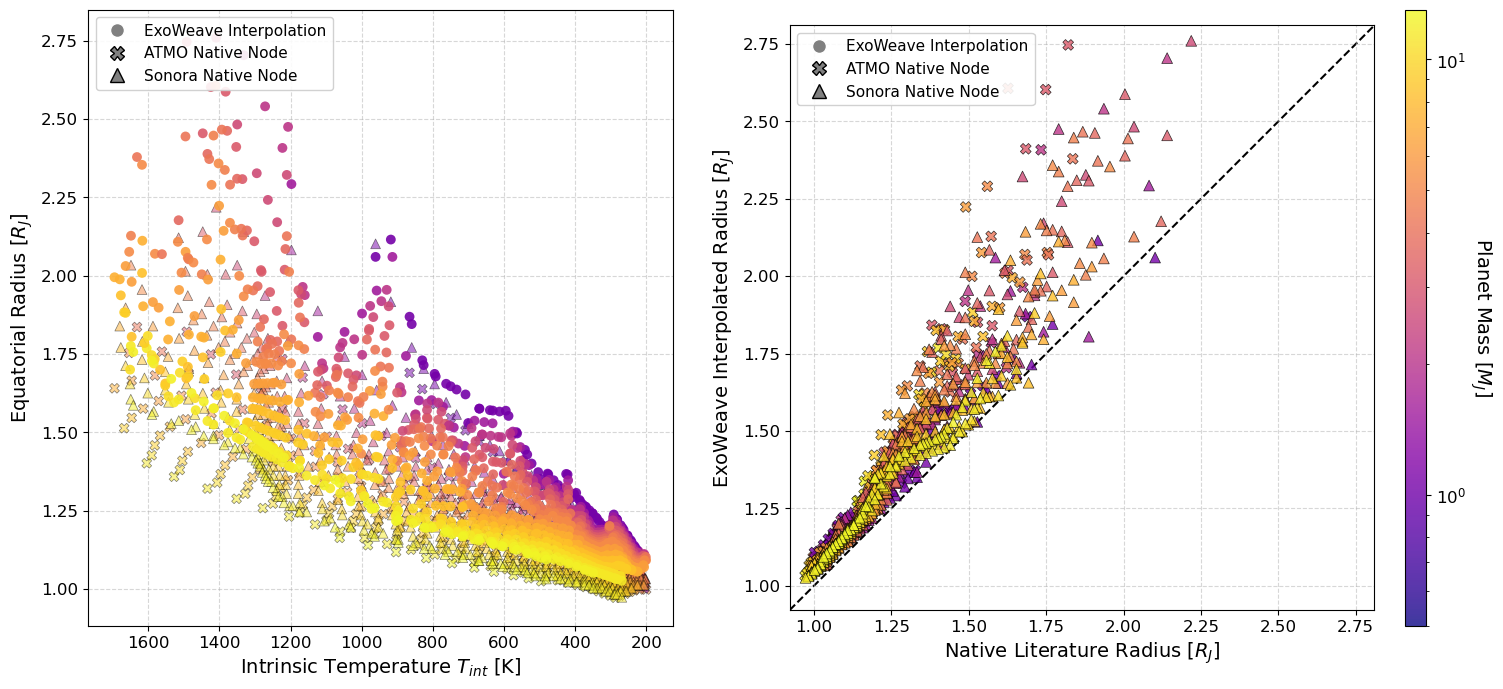

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from scipy.interpolate import LinearNDInterpolator

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
target_base = {'Met': 0.0, 'core': 10.0, 
                'f_sed_refractory': 3.0, 
                'f_sed_volatile': 3.0,  
                'kzz': 8.0, 'T_irr': 0.0}

M_SUN_TO_MJUP = 1047.3486
R_SUN_TO_RJUP = 9.731

# STRICT MASS BOUNDS
MIN_MASS_LIMIT = 0.5
MAX_MASS_LIMIT = 13.0

# =====================================================================
# 2. SCATTERED-DATA SURFACE INTERPOLATOR (LinearNDInterpolator)
# =====================================================================
print("Preparing Scattered Data Surface Interpolator...")

# Filter the master df and APPLY STRICT MASS BOUNDS
exo_base = df[
    (np.isclose(df['Met'], target_base['Met'], atol=0.1)) &
    (np.isclose(df['core'], target_base['core'], atol=1.0)) &
    (np.isclose(df['f_sed_refractory'], target_base['f_sed_refractory'], atol=0.1)) &
     (np.isclose(df['f_sed_volatile'], target_base['f_sed_volatile'], atol=0.1)) &
    (np.isclose(df['kzz'], target_base['kzz'], atol=0.1)) &
    (np.isclose(df['T_irr'], target_base['T_irr'], atol=101)) &
    (pd.to_numeric(df['mass_Mj'], errors='coerce') >= MIN_MASS_LIMIT) &
    (pd.to_numeric(df['mass_Mj'], errors='coerce') <= MAX_MASS_LIMIT)
].copy()

# Force numeric to kill hidden strings
exo_base['mass_Mj'] = pd.to_numeric(exo_base['mass_Mj'], errors='coerce')
exo_base['T_int'] = pd.to_numeric(exo_base['T_int'], errors='coerce')
exo_base['Req_Rj'] = pd.to_numeric(exo_base['Req_Rj'], errors='coerce')
exo_base = exo_base.dropna(subset=['mass_Mj', 'T_int', 'Req_Rj'])

print(f"✅ Cleaned ExoWeave cloud contains {len(exo_base)} valid points between {MIN_MASS_LIMIT} and {MAX_MASS_LIMIT} Mjup.")

if len(exo_base) > 0:
    points = np.column_stack((exo_base['mass_Mj'].values, exo_base['T_int'].values))
    values = exo_base['Req_Rj'].values
    exo_surface_interpolator = LinearNDInterpolator(points, values)
else:
    print("❌ CRITICAL: No data left after cleaning!")
    exo_surface_interpolator = None

def get_exact_exoweave_radius(target_m, target_t):
    """Evaluates the 2D surface at the exact target coordinate."""
    if exo_surface_interpolator is None: return np.nan
    return float(exo_surface_interpolator(target_m, target_t))

# =====================================================================
# 3. ATMO LOADER & EVALUATOR
# =====================================================================
ATMO_DIR = "/travail/cwilkinson/cooltrack/data/ATMO_2020_models/evolutionary_tracks/ATMO_NEQ_weak/JWST_photometry/JWST_phot_MIRI"

print("Evaluating against strictly bounded ATMO grid points...")
atmo_results = {'mass': [], 'temp': [], 'r_atmo': [], 'r_exo': []}

for f in os.listdir(ATMO_DIR):
    if f.endswith("_ATMO_NEQ_weak_vega_MIRI.txt"):
        atmo_mass_mjup = float(f.split('_')[0]) * M_SUN_TO_MJUP
        
        # APPLY STRICT MASS BOUNDS
        if MIN_MASS_LIMIT <= atmo_mass_mjup <= MAX_MASS_LIMIT:
            data = np.loadtxt(os.path.join(ATMO_DIR, f), skiprows=2)
            t_arr, r_arr = data[:, 2], data[:, 4] * R_SUN_TO_RJUP
            
            for t_val, r_val in zip(t_arr, r_arr):
                r_exo = get_exact_exoweave_radius(atmo_mass_mjup, t_val)
                if not np.isnan(r_exo):
                    atmo_results['mass'].append(atmo_mass_mjup)
                    atmo_results['temp'].append(t_val)
                    atmo_results['r_atmo'].append(r_val)
                    atmo_results['r_exo'].append(r_exo)

# =====================================================================
# 4. SONORA LOADER & EVALUATOR
# =====================================================================
SONORA_FILE = "/travail/cwilkinson/cooltrack/data/sonora/evolution/SonoraVI-RedDiamondback_Zp000_mass"

print("Evaluating against strictly bounded Sonora grid points...")
sonora_data = []
with open(SONORA_FILE, 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 6 and parts[0][0].isdigit() and '.' in parts[0]:
            try: sonora_data.append([float(parts[0]), float(parts[3]), float(parts[5])])
            except ValueError: pass

sonora_df = pd.DataFrame(sonora_data, columns=['mass_Msun', 'Teff', 'Radius_Rsun'])
sonora_df['mass_Mjup'] = sonora_df['mass_Msun'] * M_SUN_TO_MJUP
sonora_df['Radius_Rjup'] = sonora_df['Radius_Rsun'] * R_SUN_TO_RJUP

sonora_results = {'mass': [], 'temp': [], 'r_sonora': [], 'r_exo': []}

for sonora_mass, track in sonora_df.groupby('mass_Mjup'):
    # APPLY STRICT MASS BOUNDS
    if MIN_MASS_LIMIT <= sonora_mass <= MAX_MASS_LIMIT:
        t_arr, r_arr = track['Teff'].values, track['Radius_Rjup'].values
        
        for t_val, r_val in zip(t_arr, r_arr):
            r_exo = get_exact_exoweave_radius(sonora_mass, t_val)
            if not np.isnan(r_exo):
                sonora_results['mass'].append(sonora_mass)
                sonora_results['temp'].append(t_val)
                sonora_results['r_sonora'].append(r_val)
                sonora_results['r_exo'].append(r_exo)

# =====================================================================
# 5. GENERATE CONTINUOUS COLORMAPPED PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Lock the colorbar dynamically to your exact requested limits
norm = LogNorm(vmin=MIN_MASS_LIMIT, vmax=MAX_MASS_LIMIT)
cmap = 'plasma' # <-- MATCHED PALETTE HERE

# --- PANEL 1: Temperature vs. Radius ---
if len(atmo_results['mass']) > 0:
    ax1.scatter(atmo_results['temp'], atmo_results['r_exo'], c=atmo_results['mass'], 
                norm=norm, cmap=cmap, s=50, edgecolor='none', marker='o', alpha=0.9, zorder=4)
    ax1.scatter(atmo_results['temp'], atmo_results['r_atmo'], c=atmo_results['mass'], 
                norm=norm, cmap=cmap, s=50, edgecolor='black', linewidths=0.5, marker='X', alpha=0.5, zorder=3)

if len(sonora_results['mass']) > 0:
    ax1.scatter(sonora_results['temp'], sonora_results['r_exo'], c=sonora_results['mass'], 
                norm=norm, cmap=cmap, s=50, edgecolor='none', marker='o', alpha=0.9, zorder=4)
    ax1.scatter(sonora_results['temp'], sonora_results['r_sonora'], c=sonora_results['mass'], 
                norm=norm, cmap=cmap, s=50, edgecolor='black', linewidths=0.5, marker='^', alpha=0.5, zorder=3)

ax1.invert_xaxis() 
ax1.set_xlabel('Intrinsic Temperature $T_{int}$ [K]', fontsize=14)
ax1.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
#ax1.set_title(f'ExoWeave Surface Mapped onto Literature Nodes ({MIN_MASS_LIMIT} - {MAX_MASS_LIMIT} $M_J$)', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- PANEL 2: Parity Plot ---
all_r = atmo_results['r_atmo'] + atmo_results['r_exo'] + sonora_results['r_sonora'] + sonora_results['r_exo']
if len(all_r) > 0:
    min_r, max_r = min(all_r) - 0.05, max(all_r) + 0.05
else:
    min_r, max_r = 0.8, 2.0

ax2.plot([min_r, max_r], [min_r, max_r], color='black', linestyle='--', zorder=1, label='Perfect Agreement (y = x)')

if len(atmo_results['mass']) > 0:
    sc_atmo = ax2.scatter(atmo_results['r_atmo'], atmo_results['r_exo'], c=atmo_results['mass'], 
                          norm=norm, cmap=cmap, s=60, edgecolor='black', linewidths=0.5, marker='X', alpha=0.8, zorder=3)

if len(sonora_results['mass']) > 0:
    sc_sonora = ax2.scatter(sonora_results['r_sonora'], sonora_results['r_exo'], c=sonora_results['mass'], 
                            norm=norm, cmap=cmap, s=60, edgecolor='black', linewidths=0.5, marker='^', alpha=0.8, zorder=3)

ax2.set_xlim(min_r, max_r)
ax2.set_ylim(min_r, max_r)
ax2.set_aspect('equal')
ax2.set_xlabel('Native Literature Radius [$R_J$]', fontsize=14)
ax2.set_ylabel('ExoWeave Interpolated Radius [$R_J$]', fontsize=14)
#ax2.set_title('Grid Agreement (Parity Plot)', fontsize=16)
ax2.grid(True, linestyle='--', alpha=0.5)

# --- Formatting ---
try:
    active_sc = sc_sonora if 'sc_sonora' in locals() else sc_atmo
    cbar = fig.colorbar(active_sc, ax=[ax1, ax2], pad=0.02, aspect=30)
    cbar.set_label('Planet Mass [$M_J$]', rotation=270, labelpad=20, fontsize=14)
except NameError:
    pass 

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='HADES Interpolation'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='ATMO Native Node'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='Sonora Native Node')
]

ax1.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
ax2.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

#fig.suptitle('Bounded State-Space Mapping: Scattered ExoWeave Evaluated at Every Literature Node', fontsize=18, y=1.05)
plt.savefig("../figures/bounded_state_space_mapping.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from scipy.interpolate import LinearNDInterpolator

# =====================================================================
# 1. CONFIGURATION
# =====================================================================
target_base = {'Met': 0.0, 'core': 10.0,
               'f_sed_refractory': 3.0, 'f_sed_volatile': 3.0,
               'kzz': 8.0, 'T_irr': 0.0}

M_SUN_TO_MJUP = 1047.3486
R_SUN_TO_RJUP = 9.731

MIN_MASS_LIMIT = 0.5
MAX_MASS_LIMIT = 13.0    # sub-D-burning; nuclear fusion not modeled

# =====================================================================
# 2. SCATTERED-DATA SURFACE INTERPOLATOR (LinearNDInterpolator)
# =====================================================================
print("Preparing Scattered Data Surface Interpolator...")

exo_base = df[
    (np.isclose(df['Met'], target_base['Met'], atol=0.1)) &
    (np.isclose(df['core'], target_base['core'], atol=1.0)) &
    (np.isclose(df['f_sed_refractory'], target_base['f_sed_refractory'], atol=0.1)) &
    (np.isclose(df['f_sed_volatile'], target_base['f_sed_volatile'], atol=0.1)) &
    (np.isclose(df['kzz'], target_base['kzz'], atol=0.1)) &
    (np.isclose(df['T_irr'], target_base['T_irr'], atol=101)) &
    (pd.to_numeric(df['mass_Mj'], errors='coerce') >= MIN_MASS_LIMIT) &
    (pd.to_numeric(df['mass_Mj'], errors='coerce') <= MAX_MASS_LIMIT)
].copy()

exo_base['mass_Mj'] = pd.to_numeric(exo_base['mass_Mj'], errors='coerce')
exo_base['T_int']   = pd.to_numeric(exo_base['T_int'],   errors='coerce')
exo_base['Req_Rj']  = pd.to_numeric(exo_base['Req_Rj'],  errors='coerce')
exo_base = exo_base.dropna(subset=['mass_Mj', 'T_int', 'Req_Rj'])

print(f"  HADES cloud: {len(exo_base)} points in [{MIN_MASS_LIMIT}, {MAX_MASS_LIMIT}] Mjup.")

if len(exo_base) > 0:
    points = np.column_stack((exo_base['mass_Mj'].values, exo_base['T_int'].values))
    values = exo_base['Req_Rj'].values
    exo_surface_interpolator = LinearNDInterpolator(points, values)
else:
    print("CRITICAL: No data left after cleaning!")
    exo_surface_interpolator = None

def get_exact_exoweave_radius(target_m, target_t):
    if exo_surface_interpolator is None:
        return np.nan
    return float(exo_surface_interpolator(target_m, target_t))

# =====================================================================
# 3. ATMO LOADER & EVALUATOR
# =====================================================================
ATMO_DIR = "/Users/cwilkinson/Documents/Work/Observatoire de Paris/Research/Research/Codes/cooltrack/data/ATMO_2020_models/evolutionary_tracks/ATMO_NEQ_weak/JWST_photometry/JWST_phot_MIRI"

print("Evaluating ATMO native nodes...")
atmo_results = {'mass': [], 'temp': [], 'r_atmo': [], 'r_exo': []}
n_skip_atmo = 0

for f in sorted(os.listdir(ATMO_DIR)):
    if f.endswith("_ATMO_NEQ_weak_vega_MIRI.txt"):
        atmo_mass_mjup = float(f.split('_')[0]) * M_SUN_TO_MJUP
        if MIN_MASS_LIMIT <= atmo_mass_mjup <= MAX_MASS_LIMIT:
            data = np.loadtxt(os.path.join(ATMO_DIR, f), skiprows=2)
            t_arr, r_arr = data[:, 2], data[:, 4] * R_SUN_TO_RJUP
            for t_val, r_val in zip(t_arr, r_arr):
                r_exo = get_exact_exoweave_radius(atmo_mass_mjup, t_val)
                if not np.isnan(r_exo):
                    atmo_results['mass'].append(atmo_mass_mjup)
                    atmo_results['temp'].append(t_val)
                    atmo_results['r_atmo'].append(r_val)
                    atmo_results['r_exo'].append(r_exo)
                else:
                    n_skip_atmo += 1

# =====================================================================
# 4. SONORA LOADER & EVALUATOR
# =====================================================================
SONORA_FILE = "../data/sonora/evolution/SonoraVI-RedDiamondback_Zp000_mass"

print("Evaluating Sonora native nodes...")
sonora_data = []
with open(SONORA_FILE, 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 6 and parts[0][0].isdigit() and '.' in parts[0]:
            try:
                sonora_data.append([float(parts[0]), float(parts[3]), float(parts[5])])
            except ValueError:
                pass

sonora_df = pd.DataFrame(sonora_data, columns=['mass_Msun', 'Teff', 'Radius_Rsun'])
sonora_df['mass_Mjup']   = sonora_df['mass_Msun']   * M_SUN_TO_MJUP
sonora_df['Radius_Rjup'] = sonora_df['Radius_Rsun'] * R_SUN_TO_RJUP

sonora_results = {'mass': [], 'temp': [], 'r_sonora': [], 'r_exo': []}
n_skip_sonora = 0

for sonora_mass, track in sonora_df.groupby('mass_Mjup'):
    if MIN_MASS_LIMIT <= sonora_mass <= MAX_MASS_LIMIT:
        t_arr, r_arr = track['Teff'].values, track['Radius_Rjup'].values
        for t_val, r_val in zip(t_arr, r_arr):
            r_exo = get_exact_exoweave_radius(sonora_mass, t_val)
            if not np.isnan(r_exo):
                sonora_results['mass'].append(sonora_mass)
                sonora_results['temp'].append(t_val)
                sonora_results['r_sonora'].append(r_val)
                sonora_results['r_exo'].append(r_exo)
            else:
                n_skip_sonora += 1

# =====================================================================
# 5. REPORT
# =====================================================================
def _stats(d):
    d = np.asarray(d, float)
    if len(d) == 0:
        return dict(n=0, median=np.nan, mean=np.nan, rms=np.nan,
                    p16=np.nan, p84=np.nan, max_abs=np.nan)
    return dict(n=int(len(d)), median=float(np.median(d)), mean=float(np.mean(d)),
                rms=float(np.sqrt(np.mean(d**2))),
                p16=float(np.percentile(d, 16)), p84=float(np.percentile(d, 84)),
                max_abs=float(np.max(np.abs(d))))

def report(label, mass, temp, r_lit, r_exo, n_skip):
    mass  = np.asarray(mass,  float); temp  = np.asarray(temp,  float)
    r_lit = np.asarray(r_lit, float); r_exo = np.asarray(r_exo, float)
    n_in = len(r_lit); n_tot = n_in + n_skip
    cov  = (100.0 * n_in / n_tot) if n_tot else float('nan')
    d  = r_exo - r_lit
    dp = 100.0 * d / r_lit
    sa, sp = _stats(d), _stats(dp)
    print(f"\n--- {label} ---")
    print(f"  evaluations : in-hull {n_in} | out-of-hull (NaN) {n_skip} | coverage {cov:.1f}%")
    if n_in == 0:
        print("  (no points inside the HADES hull)"); return
    print(f"  R_exo - R_lit  [Rj] : median {sa['median']:+.3f} | mean {sa['mean']:+.3f} | "
          f"rms {sa['rms']:.3f} | 16-84 [{sa['p16']:+.3f}, {sa['p84']:+.3f}] | max|.| {sa['max_abs']:.3f}")
    print(f"  dR/R           [%]  : median {sp['median']:+.2f} | mean {sp['mean']:+.2f} | "
          f"rms {sp['rms']:.2f} | 16-84 [{sp['p16']:+.2f}, {sp['p84']:+.2f}] | max|.| {sp['max_abs']:.2f}")
    edges = [0.5, 1.0, 3.0, 7.0, 13.0]
    print("  by mass:")
    print(f"    {'M [Mj]':>9} | {'N':>4} | {'median dR%':>11} | {'rms dR%':>9} | {'max|dR|%':>9}")
    for a, b in zip(edges[:-1], edges[1:]):
        m = (mass>=a)&(mass<b) if b != edges[-1] else (mass>=a)&(mass<=b)
        if not m.any():
            print(f"    {a:>3.1f}-{b:<5.1f}| {0:>4} |          - |         - |         -"); continue
        ddp = dp[m]
        print(f"    {a:>3.1f}-{b:<5.1f}| {m.sum():>4} | {np.median(ddp):>+11.2f} | "
              f"{np.sqrt(np.mean(ddp**2)):>9.2f} | {np.max(np.abs(ddp)):>9.2f}")
    tedges = [200, 500, 1000, 1500, 2000, 3000]
    print("  by Teff:")
    print(f"    {'Teff [K]':>11} | {'N':>4} | {'median dR%':>11} | {'rms dR%':>9} | {'max|dR|%':>9}")
    for a, b in zip(tedges[:-1], tedges[1:]):
        m = (temp>=a)&(temp<b) if b != tedges[-1] else (temp>=a)&(temp<=b)
        if not m.any():
            print(f"    {a:>4d}-{b:<6d}| {0:>4} |          - |         - |         -"); continue
        ddp = dp[m]
        print(f"    {a:>4d}-{b:<6d}| {m.sum():>4} | {np.median(ddp):>+11.2f} | "
              f"{np.sqrt(np.mean(ddp**2)):>9.2f} | {np.max(np.abs(ddp)):>9.2f}")
    order = np.argsort(-np.abs(dp))[:5]
    print("  top |dR%| outliers (mass, Teff, R_lit, R_exo, dR%):")
    for i in order:
        print(f"    {mass[i]:>5.2f} Mj | {temp[i]:>5.0f} K | "
              f"R_lit={r_lit[i]:.3f} | R_exo={r_exo[i]:.3f} | {dp[i]:+.2f}%")

print("\n" + "="*72)
print("HADES vs Literature  —  grid-level radius comparison report")
print("="*72)
print(f"Mass window  : {MIN_MASS_LIMIT} - {MAX_MASS_LIMIT} Mjup  (sub-D-burning)")
print(f"Caveat       : nuclear fusion not modeled in HADES; agreement near 13 Mjup")
print(f"               is only physically expected after a Kelvin-Helmholtz time")
print(f"               past any prior burning epoch.")
print(f"HADES filter : Met={target_base['Met']}  core={target_base['core']}  "
      f"fseds={target_base['f_sed_refractory']}/{target_base['f_sed_volatile']}  "
      f"kzz={target_base['kzz']}  T_irr={target_base['T_irr']}")
if len(exo_base):
    print(f"HADES cloud  : {len(exo_base)} points  |  "
          f"mass {exo_base['mass_Mj'].min():.2f}-{exo_base['mass_Mj'].max():.2f} Mj  |  "
          f"T_int {exo_base['T_int'].min():.0f}-{exo_base['T_int'].max():.0f} K  |  "
          f"R {exo_base['Req_Rj'].min():.3f}-{exo_base['Req_Rj'].max():.3f} Rj")

report("ATMO NEQ_weak (MIRI evolutionary tracks)",
       atmo_results['mass'], atmo_results['temp'],
       atmo_results['r_atmo'], atmo_results['r_exo'], n_skip_atmo)

report("Sonora RedDiamondback Zp000",
       sonora_results['mass'], sonora_results['temp'],
       sonora_results['r_sonora'], sonora_results['r_exo'], n_skip_sonora)

# combined
combined_mass  = atmo_results['mass']  + sonora_results['mass']
combined_temp  = atmo_results['temp']  + sonora_results['temp']
combined_rlit  = atmo_results['r_atmo'] + sonora_results['r_sonora']
combined_rexo  = atmo_results['r_exo']  + sonora_results['r_exo']
report("COMBINED (ATMO + Sonora)",
       combined_mass, combined_temp, combined_rlit, combined_rexo,
       n_skip_atmo + n_skip_sonora)

print("\n" + "="*72)

# =====================================================================
# 6. GENERATE CONTINUOUS COLORMAPPED PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
norm = LogNorm(vmin=MIN_MASS_LIMIT, vmax=MAX_MASS_LIMIT)
cmap = 'plasma'

if len(atmo_results['mass']) > 0:
    ax1.scatter(atmo_results['temp'], atmo_results['r_exo'], c=atmo_results['mass'],
                norm=norm, cmap=cmap, s=50, edgecolor='none',  marker='o', alpha=0.9, zorder=4)
    ax1.scatter(atmo_results['temp'], atmo_results['r_atmo'], c=atmo_results['mass'],
                norm=norm, cmap=cmap, s=50, edgecolor='black', linewidths=0.5, marker='X', alpha=0.5, zorder=3)
if len(sonora_results['mass']) > 0:
    ax1.scatter(sonora_results['temp'], sonora_results['r_exo'], c=sonora_results['mass'],
                norm=norm, cmap=cmap, s=50, edgecolor='none',  marker='o', alpha=0.9, zorder=4)
    ax1.scatter(sonora_results['temp'], sonora_results['r_sonora'], c=sonora_results['mass'],
                norm=norm, cmap=cmap, s=50, edgecolor='black', linewidths=0.5, marker='^', alpha=0.5, zorder=3)

ax1.invert_xaxis()
ax1.set_xlabel(r'Intrinsic Temperature $T_{int}$ [K]', fontsize=14)
ax1.set_ylabel(r'Equatorial Radius [$R_J$]', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)

all_r = atmo_results['r_atmo'] + atmo_results['r_exo'] + sonora_results['r_sonora'] + sonora_results['r_exo']
min_r, max_r = (min(all_r) - 0.05, max(all_r) + 0.05) if len(all_r) else (0.8, 2.0)
ax2.plot([min_r, max_r], [min_r, max_r], color='black', linestyle='--', zorder=1, label='Perfect Agreement (y = x)')
sc_atmo = sc_sonora = None
if len(atmo_results['mass']) > 0:
    sc_atmo = ax2.scatter(atmo_results['r_atmo'], atmo_results['r_exo'], c=atmo_results['mass'],
                          norm=norm, cmap=cmap, s=60, edgecolor='black', linewidths=0.5, marker='X', alpha=0.8, zorder=3)
if len(sonora_results['mass']) > 0:
    sc_sonora = ax2.scatter(sonora_results['r_sonora'], sonora_results['r_exo'], c=sonora_results['mass'],
                            norm=norm, cmap=cmap, s=60, edgecolor='black', linewidths=0.5, marker='^', alpha=0.8, zorder=3)

ax2.set_xlim(min_r, max_r); ax2.set_ylim(min_r, max_r); ax2.set_aspect('equal')
ax2.set_xlabel(r'Native Literature Radius [$R_J$]', fontsize=14)
ax2.set_ylabel(r'ExoWeave Interpolated Radius [$R_J$]', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)

active_sc = sc_sonora if sc_sonora is not None else sc_atmo
if active_sc is not None:
    cbar = fig.colorbar(active_sc, ax=[ax1, ax2], pad=0.02, aspect=30)
    cbar.set_label(r'Planet Mass [$M_J$]', rotation=270, labelpad=20, fontsize=14)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='HADES Interpolation'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='ATMO Native Node'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='Sonora Native Node'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
ax2.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

plt.savefig("../figures/bounded_state_space_mapping.pdf", dpi=300, bbox_inches='tight')
plt.show()

Preparing Scattered Data Surface Interpolator...
  HADES cloud: 750 points in [0.5, 13.0] Mjup.
Evaluating ATMO native nodes...


FileNotFoundError: [Errno 2] No such file or directory: '/travail/cwilkinson/cooltrack/data/ATMO_2020_models/evolutionary_tracks/ATMO_NEQ_weak/JWST_photometry/JWST_phot_MIRI'

Plotting 5226 well-converged ExoWeave points...


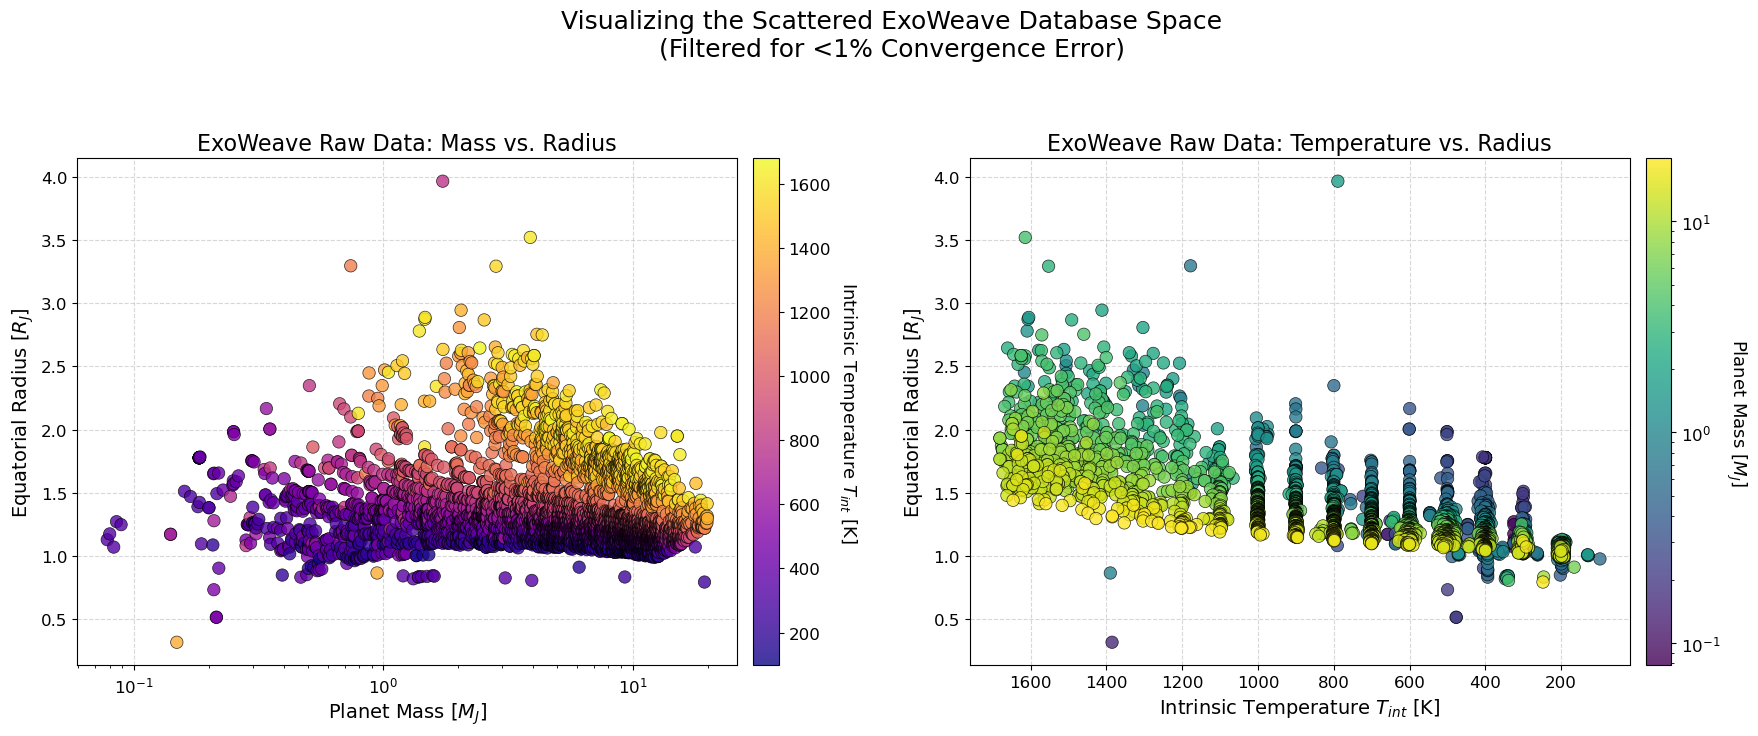

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# =====================================================================
# 0. CALCULATE CONVERGENCE ERROR (NEW)
# =====================================================================
# Calculate the percentage difference between the requested dial and the true physics
df['Tint_Error_Percent'] = (np.abs(df['T_int_input_dial'] - df['T_int']) / df['T_int']) * 100

# =====================================================================
# 1. FILTER THE RAW DATA
# =====================================================================
target_base = {'Met': 0.0, 'core': 10.0, 'f_sed': 3.0, 'kzz': 8.0, 'T_irr': 0.0}

exo_base = df[
    (df['Tint_Error_Percent'] <= 5.0) &  # <-- NEW: 1% Convergence Tolerance Filter
    #(np.isclose(df['Met'], target_base['Met'], atol=0.1)) &
    #(np.isclose(df['core'], target_base['core'], atol=1.0)) &
    #(np.isclose(df['f_sed'], target_base['f_sed'], atol=0.1)) &
    #(np.isclose(df['kzz'], target_base['kzz'], atol=0.1)) &
    (np.isclose(df['T_irr'], target_base['T_irr'], atol=101))
].copy()

# Force numeric to ensure no hidden strings break the plotter
# (Updated to use T_int_true_K for physical accuracy)
for col in ['mass_Mj', 'T_int', 'Req_Rj']:
    exo_base[col] = pd.to_numeric(exo_base[col], errors='coerce')

# Drop any NaN failures
exo_base = exo_base.dropna(subset=['mass_Mj', 'T_int', 'Req_Rj'])

print(f"Plotting {len(exo_base)} well-converged ExoWeave points...")

# =====================================================================
# 2. GENERATE THE SCATTER PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PANEL 1: Mass vs. Radius (Colored by Temp) ---
sc1 = ax1.scatter(exo_base['mass_Mj'], exo_base['Req_Rj'], 
                  c=exo_base['T_int'], cmap='plasma', 
                  edgecolor='black', linewidth=0.5, s=80, alpha=0.8, zorder=3)

ax1.set_xlabel('Planet Mass [$M_J$]', fontsize=14)
ax1.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax1.set_title('ExoWeave Raw Data: Mass vs. Radius', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax1.set_xscale('log')

cbar1 = fig.colorbar(sc1, ax=ax1, pad=0.02)
cbar1.set_label('Intrinsic Temperature $T_{int}$ [K]', rotation=270, labelpad=20, fontsize=13)

# --- PANEL 2: Temperature vs. Radius (Colored by Mass) ---
sc2 = ax2.scatter(exo_base['T_int'], exo_base['Req_Rj'], 
                  c=exo_base['mass_Mj'], cmap='viridis', norm=LogNorm(),
                  edgecolor='black', linewidth=0.5, s=80, alpha=0.8, zorder=3)

ax2.invert_xaxis()  # Hot on the left, cooling to the right
ax2.set_xlabel('Intrinsic Temperature $T_{int}$ [K]', fontsize=14)
ax2.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax2.set_title('ExoWeave Raw Data: Temperature vs. Radius', fontsize=16)
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)

cbar2 = fig.colorbar(sc2, ax=ax2, pad=0.02)
cbar2.set_label('Planet Mass [$M_J$]', rotation=270, labelpad=20, fontsize=13)

fig.suptitle('Visualizing the Scattered ExoWeave Database Space\n(Filtered for <1% Convergence Error)', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# =====================================================================
# 1. FILTER THE RAW DATA EXACTLY AS BEFORE
# =====================================================================
target_base = {'Met': 0.0, 'core': 10.0, 'f_sed': 3.0, 'kzz': 8.0, 'T_irr': 0.0}

exo_base = df[
    (np.isclose(df['Met'], target_base['Met'], atol=0.1)) &
    (np.isclose(df['core'], target_base['core'], atol=1.0)) &
    (np.isclose(df['f_sed'], target_base['f_sed'], atol=0.1)) &
    (np.isclose(df['kzz'], target_base['kzz'], atol=0.1)) &
    (np.isclose(df['T_irr'], target_base['T_irr'], atol=101))
].copy()

# Force numeric to ensure no hidden strings break the plotter
for col in ['mass_Mj', 'T_int', 'Req_Rj']:
    exo_base[col] = pd.to_numeric(exo_base[col], errors='coerce')

# Drop any NaN failures
exo_base = exo_base.dropna(subset=['mass_Mj', 'T_int', 'Req_Rj'])

print(f"Plotting {len(exo_base)} raw ExoWeave points...")

# =====================================================================
# 2. GENERATE THE SCATTER PLOTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PANEL 1: Mass vs. Radius (Colored by Temp) ---
sc1 = ax1.scatter(exo_base['mass_Mj'], exo_base['Req_Rj'], 
                  c=exo_base['T_eff'], cmap='plasma', 
                  edgecolor='black', linewidth=0.5, s=80, alpha=0.8, zorder=3)

ax1.set_xlabel('Planet Mass [$M_J$]', fontsize=14)
ax1.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax1.set_title('ExoWeave Raw Data: Mass vs. Radius', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax1.set_xscale('log')

cbar1 = fig.colorbar(sc1, ax=ax1, pad=0.02)
cbar1.set_label('Intrinsic Temperature $T_{int}$ [K]', rotation=270, labelpad=20, fontsize=13)

# --- PANEL 2: Temperature vs. Radius (Colored by Mass) ---
sc2 = ax2.scatter(exo_base['T_eff'], exo_base['Req_Rj'], 
                  c=exo_base['mass_Mj'], cmap='viridis', norm=LogNorm(),
                  edgecolor='black', linewidth=0.5, s=80, alpha=0.8, zorder=3)

ax2.invert_xaxis()  # Hot on the left, cooling to the right
ax2.set_xlabel('Intrinsic Temperature $T_{int}$ [K]', fontsize=14)
ax2.set_ylabel('Equatorial Radius [$R_J$]', fontsize=14)
ax2.set_title('ExoWeave Raw Data: Temperature vs. Radius', fontsize=16)
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)

cbar2 = fig.colorbar(sc2, ax=ax2, pad=0.02)
cbar2.set_label('Planet Mass [$M_J$]', rotation=270, labelpad=20, fontsize=13)

fig.suptitle('Visualizing the Scattered ExoWeave Database Space', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

KeyError: 'f_sed'

In [ ]:
list(exo_base.columns)

['mass',
 'T_int',
 'T_int_input_dial',
 'T_irr',
 'T_eff',
 'Met',
 'core',
 'f_sed',
 'kzz',
 'Req',
 'dsdt',
 'S_physical',
 'JWST/NIRCam.F070W',
 'JWST/NIRCam.F090W',
 'JWST/NIRCam.F115W',
 'JWST/NIRCam.F140M',
 'JWST/NIRCam.F150W',
 'JWST/NIRCam.F182M',
 'JWST/NIRCam.F200W',
 'JWST/NIRCam.F210M',
 'JWST/NIRCam.F250M',
 'JWST/NIRCam.F277W',
 'JWST/NIRCam.F300M',
 'JWST/NIRCam.F335M',
 'JWST/NIRCam.F356W',
 'JWST/NIRCam.F410M',
 'JWST/NIRCam.F430M',
 'JWST/NIRCam.F444W',
 'JWST/NIRCam.F460M',
 'JWST/NIRCam.F480M',
 'JWST/MIRI.F560W',
 'JWST/MIRI.F770W',
 'JWST/MIRI.F1000W',
 'JWST/MIRI.F1130W',
 'JWST/MIRI.F1280W',
 'JWST/MIRI.F1500W',
 'JWST/MIRI.F1800W',
 'JWST/MIRI.F2100W',
 'JWST/MIRI.F2550W',
 'JWST/NIRISS.F090W',
 'JWST/NIRISS.F115W',
 'JWST/NIRISS.F140M',
 'JWST/NIRISS.F150W',
 'JWST/NIRISS.F158M',
 'JWST/NIRISS.F200W',
 'JWST/NIRISS.F277W',
 'JWST/NIRISS.F380M',
 'JWST/NIRISS.F430M',
 'JWST/NIRISS.F480M',
 'Paranal/SPHERE.IRDIS_B_Y',
 'Paranal/SPHERE.IRDIS_B_J',
 'Paranal/SP